# Save RNA count to mtx

In [1]:
.libPaths(c("/usr/lib/R/library/", "/usr/local/lib/R/site-library/"))

In [2]:
suppressPackageStartupMessages({
    library(Seurat)
    library(SeuratDisk)
    library(repr)
    library(patchwork)
    library(ggplot2)
    library(Signac)
    library(tidyverse)
    library(GenomicRanges)
    library(Matrix)
    library(ggrepel)
    library(fs)
    library(pheatmap)
    library(gridExtra)
    library(RColorBrewer)
    library(data.table)
    library(ComplexHeatmap)
})
options(future.globals.maxSize = Inf)
options(Seurat.object.assay.version = "v5")
options(ggrepel.max.overlaps = Inf)

In [4]:
obj <- readRDS("mouseAD_5xFAD_RNA_Microglia_wo_PVM.rds")
obj

An object of class Seurat 
64570 features across 40553 samples within 2 assays 
Active assay: RNA (32285 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: sketch
 5 dimensional reductions calculated: pca, umap, pca.full, full.umap, full.umap.1

In [5]:
writeMM(LayerData(obj, layer = "counts", assay = "RNA"), "./micro-rna.mtx")

NULL

In [6]:
write.table(
    colnames(obj), 
    "./micro-barcodes.tsv",
    col.names = FALSE, 
    quote = FALSE, 
    sep = "\t", 
    row.names = FALSE
)

In [7]:
write.table(
    rownames(obj), 
    "./micro-genes.tsv",
    col.names = FALSE, 
    quote = FALSE, 
    sep = "\t", 
    row.names = FALSE
)

In [8]:
write.table(
    obj@meta.data,
    "./micro-meta.tsv",
    col.names = TRUE, 
    quote = FALSE, 
    sep = "\t", 
    row.names = TRUE
)

In [9]:
head(colnames(obj))

[1] "3C_Xu_1_2_AAACCGAAGCCGGTAC-1" "3C_Xu_1_2_AAAGCGGGTTTATTCG-1"
[3] "3C_Xu_1_2_AAAGCGGGTTTGTGGA-1" "3C_Xu_1_2_AAAGGACGTGAACAAA-1"
[5] "3C_Xu_1_2_AACAAAGGTTTACTTG-1" "3C_Xu_1_2_AACATTGTCCGCATGA-1"

# Export RNA data to anndata

In [1]:
import scanpy as sc
import pandas as pd

In [2]:
import os

In [3]:
from pathlib import Path

In [4]:
rna_counts = sc.read_mtx(f"micro-rna.mtx")

In [5]:
rna_counts = rna_counts.T.copy()

In [6]:
cell_meta = pd.read_csv(f"micro-meta.tsv", header=0, index_col=0, sep="\t")
gene_names = pd.read_csv(f"micro-genes.tsv", header=None, index_col=0, sep="\t")
gene_names.index.name = None

In [7]:
rna_counts.obs = cell_meta
rna_counts.var = gene_names

In [8]:
rna_counts

AnnData object with n_obs × n_vars = 40553 × 32285
    obs: 'library_id', 'index', 'orig.ident.x', 'nCount_RNA', 'nFeature_RNA', 'scrubDoublets', 'doublet_scores_obs', 'cell_barcode', 'qc_pass', 'percent.mt', 'tsse', 'frac_dup', 'n_fragment', 'frac_mito', 'doublet_score', 'leverage.score', 'seurat_clusters', 'cluster_full', 'cluster_full.score', 'predicted_allen_class', 'predicted_allen_subclass', 'leverage.score.1', 'subclass', 'neurotransmitter', 'class', 'Senescence_score1', 'group', 'nCount_RNA.trans', 'nFeature_RNA.trans', 'hAPP', 'hPSEN1', 'final_cluster', 'final_celltype', 'final_cluster_color', 'final_celltype_color', 'final_group', 'mouse_id', 'genotype', 'sex', 'age', 'intervention', 'Interferon_related_score1', 'MHC_class_I_score1', 'Activation_Disease_association_score1'

In [9]:
rna_counts.raw = rna_counts.copy()
sc.pp.normalize_total(rna_counts, target_sum=1e4)
sc.pp.log1p(rna_counts)
sc.pp.highly_variable_genes(rna_counts, min_mean=0.0125, max_mean=3, min_disp=0.5)
rna_counts = rna_counts[:, rna_counts.var.highly_variable]
sc.pp.scale(rna_counts, max_value=10)

/tscc/nfs/home/biy022/miniconda3/envs/scenicplus/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:843: UserWarning: Revieved a view of an AnnData. Making a copy.
  view_to_actual(adata)


/tscc/nfs/home/biy022/miniconda3/envs/scenicplus/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tscc/nfs/home/biy022/miniconda3/envs/scenicplus/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:378: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


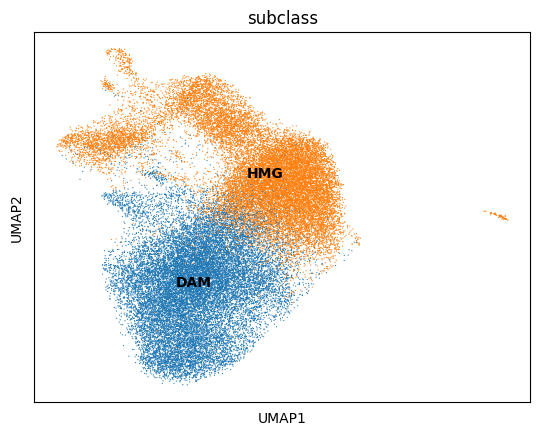

In [10]:
sc.tl.pca(rna_counts)
sc.pp.neighbors(rna_counts)
sc.tl.umap(rna_counts)
sc.pl.umap(rna_counts, color = "subclass", legend_loc="on data")

In [11]:
rna_counts.write(f"micro-rna_matrix.h5ad")

In [12]:
rna_counts

AnnData object with n_obs × n_vars = 40553 × 2389
    obs: 'library_id', 'index', 'orig.ident.x', 'nCount_RNA', 'nFeature_RNA', 'scrubDoublets', 'doublet_scores_obs', 'cell_barcode', 'qc_pass', 'percent.mt', 'tsse', 'frac_dup', 'n_fragment', 'frac_mito', 'doublet_score', 'leverage.score', 'seurat_clusters', 'cluster_full', 'cluster_full.score', 'predicted_allen_class', 'predicted_allen_subclass', 'leverage.score.1', 'subclass', 'neurotransmitter', 'class', 'Senescence_score1', 'group', 'nCount_RNA.trans', 'nFeature_RNA.trans', 'hAPP', 'hPSEN1', 'final_cluster', 'final_celltype', 'final_cluster_color', 'final_celltype_color', 'final_group', 'mouse_id', 'genotype', 'sex', 'age', 'intervention', 'Interferon_related_score1', 'MHC_class_I_score1', 'Activation_Disease_association_score1'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'subclass_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    ob